In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from hmmlearn import hmm
from extFuncs import *

In [2]:
df_nvo = dataExtracterDays('NVO', '2016-01-01', '2026-01-01')
df_nvo

[*********************100%***********************]  1 of 1 completed

The dataset has observations across 2514 days


,Date,Open,High,Low,Close
0,2016-01-04,23.377436,23.385526,22.952686,23.179218
1,2016-01-05,23.450246,23.527105,23.292482,23.454290
2,2016-01-06,23.078086,23.300574,23.053816,23.175173
3,2016-01-07,22.693789,22.839418,22.511754,22.673563
4,2016-01-08,22.665471,22.709969,22.099139,22.151726
...,...,...,...,...,...
2509,2025-12-24,52.849998,53.630001,52.000000,52.560001
2510,2025-12-26,53.020000,53.029999,51.700001,52.400002
2511,2025-12-29,51.560001,51.990002,51.349998,51.470001
2512,2025-12-30,51.520000,51.669998,51.070000,51.220001


In [3]:
def HMM_predict(obsData, train_size, window_size, Ncomp):
    obs = obsData.copy()
    obs['Return'] = obs['Close'].pct_change()
    obs = obs.dropna().reset_index(drop=True)
    
    train = obs[:train_size]
    train_data = train['Return'].values.reshape(-1, 1)
    
    # Train global HMM
    model = hmm.GaussianHMM(n_components=Ncomp, random_state=123)
    model.fit(train_data)
    
    means = model.means_
    
    print(means*100)
    print(np.round(model.transmat_, 2))
    
    
    T = max(window_size, train_size)
    predictions = []
    returns = []
    doprint = True
    while T < len(obs):
        window = obs[['Return']].iloc[T-window_size:T]

        # Probability distribution of hidden states for current step
        state_probs = model.predict_proba(window)[-1]

        # Expected distribution of hidden states for next step
        next_state_probs = state_probs @ model.transmat_

        # Expected return across all states
        predicted_return = np.dot(next_state_probs, means)
        
        if doprint:
            print(f"State probabilities: {np.round(state_probs, 2)}")
            print(f"Next state probabilities: {np.round(next_state_probs, 2)}")
            print(f"Expected return: {predicted_return}")
            doprint = False

        # Convert to price
        predicted_price = obs['Close'].iloc[T-1] * (1 + predicted_return)

        returns.append(predicted_return[0])
        predictions.append(predicted_price)
        T += 1

    close = obs['Close'].iloc[train_size:].values

    return predictions, close, returns

In [4]:
predV1, realV1, predV1Returns = HMM_predict(df_nvo, train_size=1000, window_size=200, Ncomp=3)

c:\Users\asker\anaconda3\envs\appstat\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


[[ 0.08555696]
 [-1.30040569]
 [ 0.14486879]]
[[0.74 0.03 0.23]
 [0.03 0.22 0.75]
 [0.83 0.11 0.06]]
State probabilities: [0.81 0.01 0.17]
Next state probabilities: [0.75 0.04 0.21]
Expected return: [0.00038318]


In [5]:
def HMM_predictV2(obsData, train_size, window_size, Ncomp):
    obs = obsData.copy()
    obs['Return'] = obs['Close'].pct_change()
    obs = obs.dropna().reset_index(drop=True)
    
    train = obs[:train_size]
    train_data = train['Return'].values.reshape(-1, 1)
    
    # Train global HMM
    model = hmm.GaussianHMM(n_components=Ncomp, random_state=123)
    model.fit(train_data)
    
    means = model.means_
    
    print(means*100)
    print(np.round(model.transmat_, 2))
    
    
    T = max(window_size, train_size)
    predictions = []
    returns = []
    while T < len(obs):
        window = obs[['Return']].iloc[T-window_size:T]

        # Probability distribution of hidden states for current step
        current_state = model.predict(window)[-1]

        # Expected distribution of hidden states for next step
        next_state = np.random.choice(len(means), p=model.transmat_[current_state])

        # Expected return across all states
        predicted_return = means[next_state]
        

        # Convert to price
        predicted_price = obs['Close'].iloc[T-1] * (1 + predicted_return)

        returns.append(predicted_return[0])
        predictions.append(predicted_price)
        T += 1

    close = obs['Close'].iloc[train_size:].values

    return predictions, close, returns

In [6]:
predV2, realV2, predReturnsV2 = HMM_predictV2(df_nvo, train_size=1000, window_size=200, Ncomp=3)

c:\Users\asker\anaconda3\envs\appstat\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


[[ 0.08555696]
 [-1.30040569]
 [ 0.14486879]]
[[0.74 0.03 0.23]
 [0.03 0.22 0.75]
 [0.83 0.11 0.06]]


In [15]:
def HMM_predict_log(obsData, train_size, window_size, Ncomp):
    obs = obsData.copy()
    
    obs['LogReturn'] = np.log(1 + obs['Close'].pct_change())
    obs = obs.dropna().reset_index(drop=True)
    
    train = obs[:train_size]
    train_data = train['LogReturn'].values.reshape(-1, 1)

    model = hmm.GaussianHMM(n_components=Ncomp, random_state=123)
    model.fit(train_data)

    means = model.means_.flatten()

    T = max(window_size, train_size)
    predictions = []
    returns = []

    while T < len(obs):
        window = obs[['LogReturn']].iloc[T-window_size:T]

        # Current state probabilities
        state_probs = model.predict_proba(window)[-1]

        next_state_probs = state_probs @ model.transmat_

        # Expected return across all states
        predicted_log_return = np.dot(next_state_probs, means)

        # Convert log return → price
        last_price = obs['Close'].iloc[T-1]
        predicted_price = last_price * np.exp(predicted_log_return)

        returns.append(predicted_log_return)
        predictions.append(predicted_price)

        T += 1

    close = obs['Close'].iloc[train_size:].values

    return predictions, close, returns

In [16]:
predV3, realV3, predReturnsV3 = HMM_predict_log(df_nvo, train_size=1000, window_size=200, Ncomp=3)

c:\Users\asker\anaconda3\envs\appstat\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [ ]:
def HMM_predict_deltalog(obsData, train_size, window_size, Ncomp):
    obs = obsData.copy()
    
    #Residual approach:
    obs['LogReturn'] = np.log(obs['Close'] / obs['Close'].shift(1))
    obs['DeltaReturn'] = obs['LogReturn'] - obs['LogReturn'].shift(1)
    obs = obs.dropna().reset_index(drop=True)
    
    train = obs[:train_size]
    train_data = train['DeltaReturn'].values.reshape(-1, 1)

    model = hmm.GaussianHMM(n_components=Ncomp, random_state=123)
    model.fit(train_data)

    means = model.means_.flatten()

    T = max(window_size, train_size)
    predictions = []
    returns = []

    while T < len(obs):
        window = obs[['DeltaReturn']].iloc[T-window_size:T]

        state_probs = model.predict_proba(window)[-1]
        predicted_delta = np.dot(state_probs, means)

        # reconstruct return
        prev_return = obs['LogReturn'].iloc[T-1]
        predicted_log_return = prev_return + predicted_delta

        # Convert log return → price
        last_price = obs['Close'].iloc[T-1]
        predicted_price = last_price * np.exp(predicted_log_return)

        returns.append(predicted_log_return)
        predictions.append(predicted_price)

        T += 1

    close = obs['Close'].iloc[train_size:].values

    return predictions, close, returns

In [18]:
predV4, realV4, predReturnsV4 = HMM_predict_deltalog(df_nvo, train_size=1000, window_size=200, Ncomp=5)

c:\Users\asker\anaconda3\envs\appstat\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [ ]:
def HMM_predict_deltalogmean(obsData, train_size, window_size, Ncomp):
    obs = obsData.copy()
    
    #Smoothen it out: 
    obs['LogReturn'] = np.log(obs['Close'] / obs['Close'].shift(1))
    obs['DeltaReturn'] = obs['LogReturn'].diff()
    obs['DeltaReturn_smooth'] = obs['DeltaReturn'].rolling(3).mean()
    obs = obs.dropna().reset_index(drop=True)
    
    train = obs[:train_size]
    train_data = train['DeltaReturn_smooth'].values.reshape(-1, 1)

    model = hmm.GaussianHMM(n_components=Ncomp, random_state=123)
    model.fit(train_data)

    means = model.means_.flatten()

    T = max(window_size, train_size)
    predictions = []
    returns = []

    while T < len(obs):
        window = obs[['DeltaReturn']].iloc[T-window_size:T]

        state_probs = model.predict_proba(window)[-1]
        predicted_delta = np.dot(state_probs, means)

        # reconstruct return
        prev_return = obs['LogReturn'].iloc[T-1]
        predicted_log_return = prev_return + predicted_delta

        # Convert log return → price
        last_price = obs['Close'].iloc[T-1]
        predicted_price = last_price * np.exp(predicted_log_return)

        returns.append(predicted_log_return)
        smoothed_return = np.mean(returns[-3:])  # small window
        predicted_price = last_price * np.exp(smoothed_return)
        predictions.append(predicted_price)

        T += 1

    close = obs['Close'].iloc[train_size:].values

    return predictions, close, returns

In [20]:
predV5, realV5, predReturnsV5 = HMM_predict_deltalogmean(df_nvo, train_size=1000, window_size=700, Ncomp=5)

c:\Users\asker\anaconda3\envs\appstat\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
Model is not converging.  Current: 3569.6287395553086 is not greater than 3571.3719497187617. Delta is -1.7432101634531136


In [21]:
print(len(predV1), len(realV1), len(predV2), len(realV2), len(predV3), len(realV3))

1513 1513 1513 1513 1513 1513


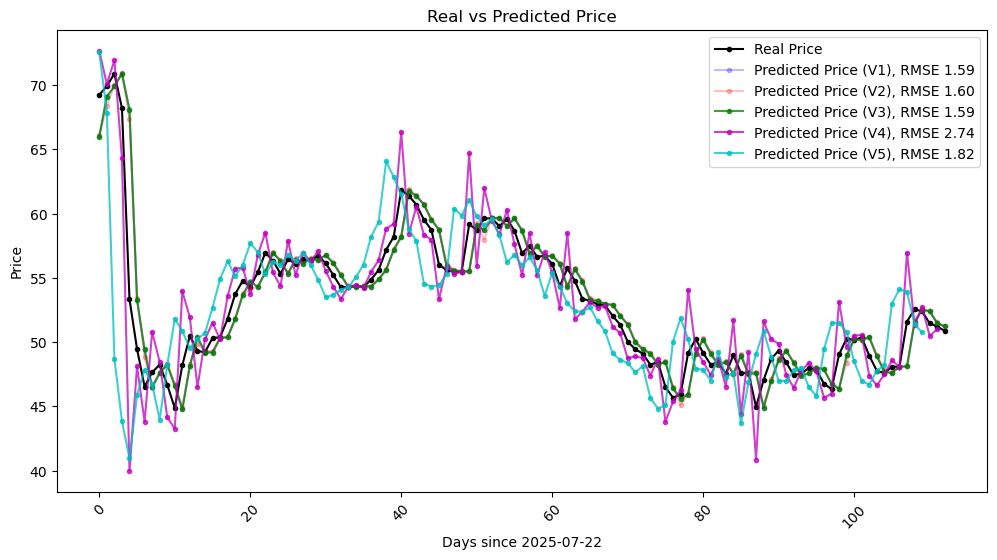

In [22]:
#Plot the predicted price against real price: 
rmseV1 = rmse(realV1, predV1)[0]
rmseV2 = rmse(realV2, predV2)[0]
rmseV3 = rmse(realV3, predV3)
rmseV4 = rmse(realV4, predV4)
rmseV5 = rmse(realV5, predV5)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(realV1[1400:], marker = '.', label='Real Price', color='k')
ax.plot(predV1[1400:], marker = '.', label=f'Predicted Price (V1), RMSE {rmseV1:.2f}', color='b', alpha = 0.25)
ax.plot(predV2[1400:], marker = '.', label=f'Predicted Price (V2), RMSE {rmseV2:.2f}', color='r', alpha = 0.25)
ax.plot(predV3[1400:], marker = '.', label=f'Predicted Price (V3), RMSE {rmseV3:.2f}', color='g', alpha = 0.75)
ax.plot(predV4[1400:], marker = '.', label=f'Predicted Price (V4), RMSE {rmseV4:.2f}', color='m', alpha = 0.75)
ax.plot(predV5[1400:], marker = '.', label=f'Predicted Price (V5), RMSE {rmseV5:.2f}', color='c', alpha = 0.75)
ax.set_title('Real vs Predicted Price')
ax.set_xlabel(f'Days since {df_nvo['Date'].iloc[1000+1400]}')
ax.set_ylabel('Price')
plt.xticks(rotation=45)
ax.legend();